In [238]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [239]:
df=pd.read_csv('balanced_1000rows_dataset.csv')
df

,Weight,Height,Color,Habitat,Animal
0,59.5,165.0,Black,Zoo,Tiger
1,87.7,116.4,Gray,Zoo,Tiger
2,213.6,88.6,White,House,Cat
3,14.8,77.8,Gray,Forest,Panther
4,40.5,107.4,White,House,Elephant
...,...,...,...,...,...
991,6.4,39.5,Gray,Forest,Cat
992,236.4,40.9,White,House,Dog
993,280.3,18.6,Yellow,Savannah,Tiger
994,15.6,168.2,Yellow,Savannah,Elephant


In [240]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Weight   996 non-null    float64
 1   Height   996 non-null    float64
 2   Color    996 non-null    object 
 3   Habitat  996 non-null    object 
 4   Animal   996 non-null    object 
dtypes: float64(2), object(3)
memory usage: 39.0+ KB


In [241]:
df.describe()


,Weight,Height
count,996.000000,996.000000
mean,165.401004,89.309940
std,88.698370,40.993887
min,1.200000,10.200000
25%,83.600000,62.400000
50%,169.000000,87.900000
75%,241.300000,118.275000
max,299.500000,168.200000


In [242]:
df.duplicated().sum()#no duplicates


np.int64(896)

<Axes: xlabel='Height', ylabel='Weight'>

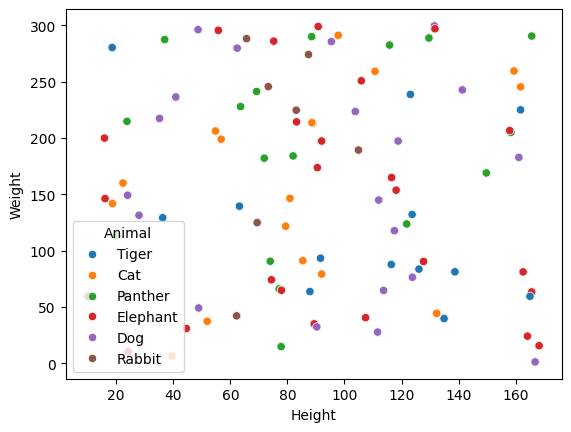

In [243]:
sns.scatterplot(x='Height',y='Weight',hue='Animal',data=df)

In [244]:
x=df.drop('Animal',axis=1)
y=df[['Animal']]
x

,Weight,Height,Color,Habitat
0,59.5,165.0,Black,Zoo
1,87.7,116.4,Gray,Zoo
2,213.6,88.6,White,House
3,14.8,77.8,Gray,Forest
4,40.5,107.4,White,House
...,...,...,...,...
991,6.4,39.5,Gray,Forest
992,236.4,40.9,White,House
993,280.3,18.6,Yellow,Savannah
994,15.6,168.2,Yellow,Savannah


In [245]:
y

,Animal
0,Tiger
1,Tiger
2,Cat
3,Panther
4,Elephant
...,...
991,Cat
992,Dog
993,Tiger
994,Elephant


<Axes: xlabel='Animal', ylabel='count'>

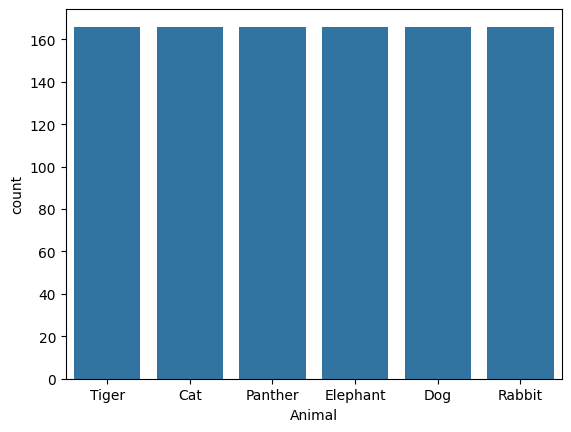

In [246]:
sns.countplot(x=y["Animal"])

In [247]:
x.select_dtypes('number')


,Weight,Height
0,59.5,165.0
1,87.7,116.4
2,213.6,88.6
3,14.8,77.8
4,40.5,107.4
...,...,...
991,6.4,39.5
992,236.4,40.9
993,280.3,18.6
994,15.6,168.2


<Axes: >

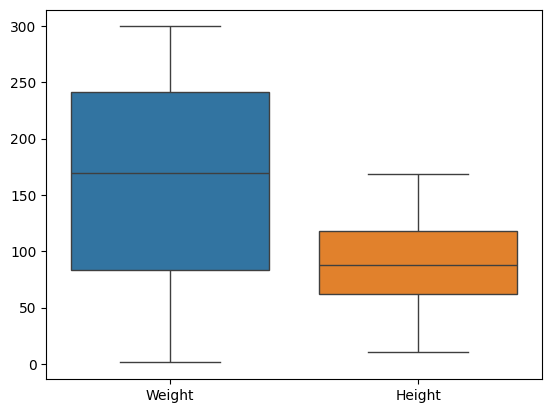

In [248]:
sns.boxplot(x.select_dtypes('number'))


In [249]:
obj=x.select_dtypes('object')
obj

,Color,Habitat
0,Black,Zoo
1,Gray,Zoo
2,White,House
3,Gray,Forest
4,White,House
...,...,...
991,Gray,Forest
992,White,House
993,Yellow,Savannah
994,Yellow,Savannah


In [250]:
obj.nunique()

Color      5
Habitat    4
dtype: int64

In [251]:
x=x.drop(obj,axis=1)
x


,Weight,Height
0,59.5,165.0
1,87.7,116.4
2,213.6,88.6
3,14.8,77.8
4,40.5,107.4
...,...,...
991,6.4,39.5
992,236.4,40.9
993,280.3,18.6
994,15.6,168.2


In [252]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder(drop='first')
obj=one.fit_transform(obj)
obj=obj.toarray()
obj=pd.DataFrame(obj)
obj.columns=one.get_feature_names_out(['Color','Habitat'])
obj

,Color_Brown,Color_Gray,Color_White,Color_Yellow,Habitat_House,Habitat_Savannah,Habitat_Zoo
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
991,0.0,1.0,0.0,0.0,0.0,0.0,0.0
992,0.0,0.0,1.0,0.0,1.0,0.0,0.0
993,0.0,0.0,0.0,1.0,0.0,1.0,0.0
994,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [253]:
x=pd.concat((x,obj),axis=1)
x.reset_index(drop=True)
x

,Weight,Height,Color_Brown,Color_Gray,Color_White,Color_Yellow,Habitat_House,Habitat_Savannah,Habitat_Zoo
0,59.5,165.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,87.7,116.4,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,213.6,88.6,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,14.8,77.8,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,40.5,107.4,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
991,6.4,39.5,0.0,1.0,0.0,0.0,0.0,0.0,0.0
992,236.4,40.9,0.0,0.0,1.0,0.0,1.0,0.0,0.0
993,280.3,18.6,0.0,0.0,0.0,1.0,0.0,1.0,0.0
994,15.6,168.2,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [254]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y['Animal'])
y=pd.DataFrame(y)
y.reset_index()
y.columns=['Animal']
y

,Animal
0,5
1,5
2,0
3,3
4,2
...,...
991,0
992,1
993,5
994,2


In [255]:
plot=x.copy()
plot['Animal']=y
plot

,Weight,Height,Color_Brown,Color_Gray,Color_White,Color_Yellow,Habitat_House,Habitat_Savannah,Habitat_Zoo,Animal
0,59.5,165.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5
1,87.7,116.4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,5
2,213.6,88.6,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
3,14.8,77.8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3
4,40.5,107.4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...
991,6.4,39.5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
992,236.4,40.9,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
993,280.3,18.6,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5
994,15.6,168.2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2


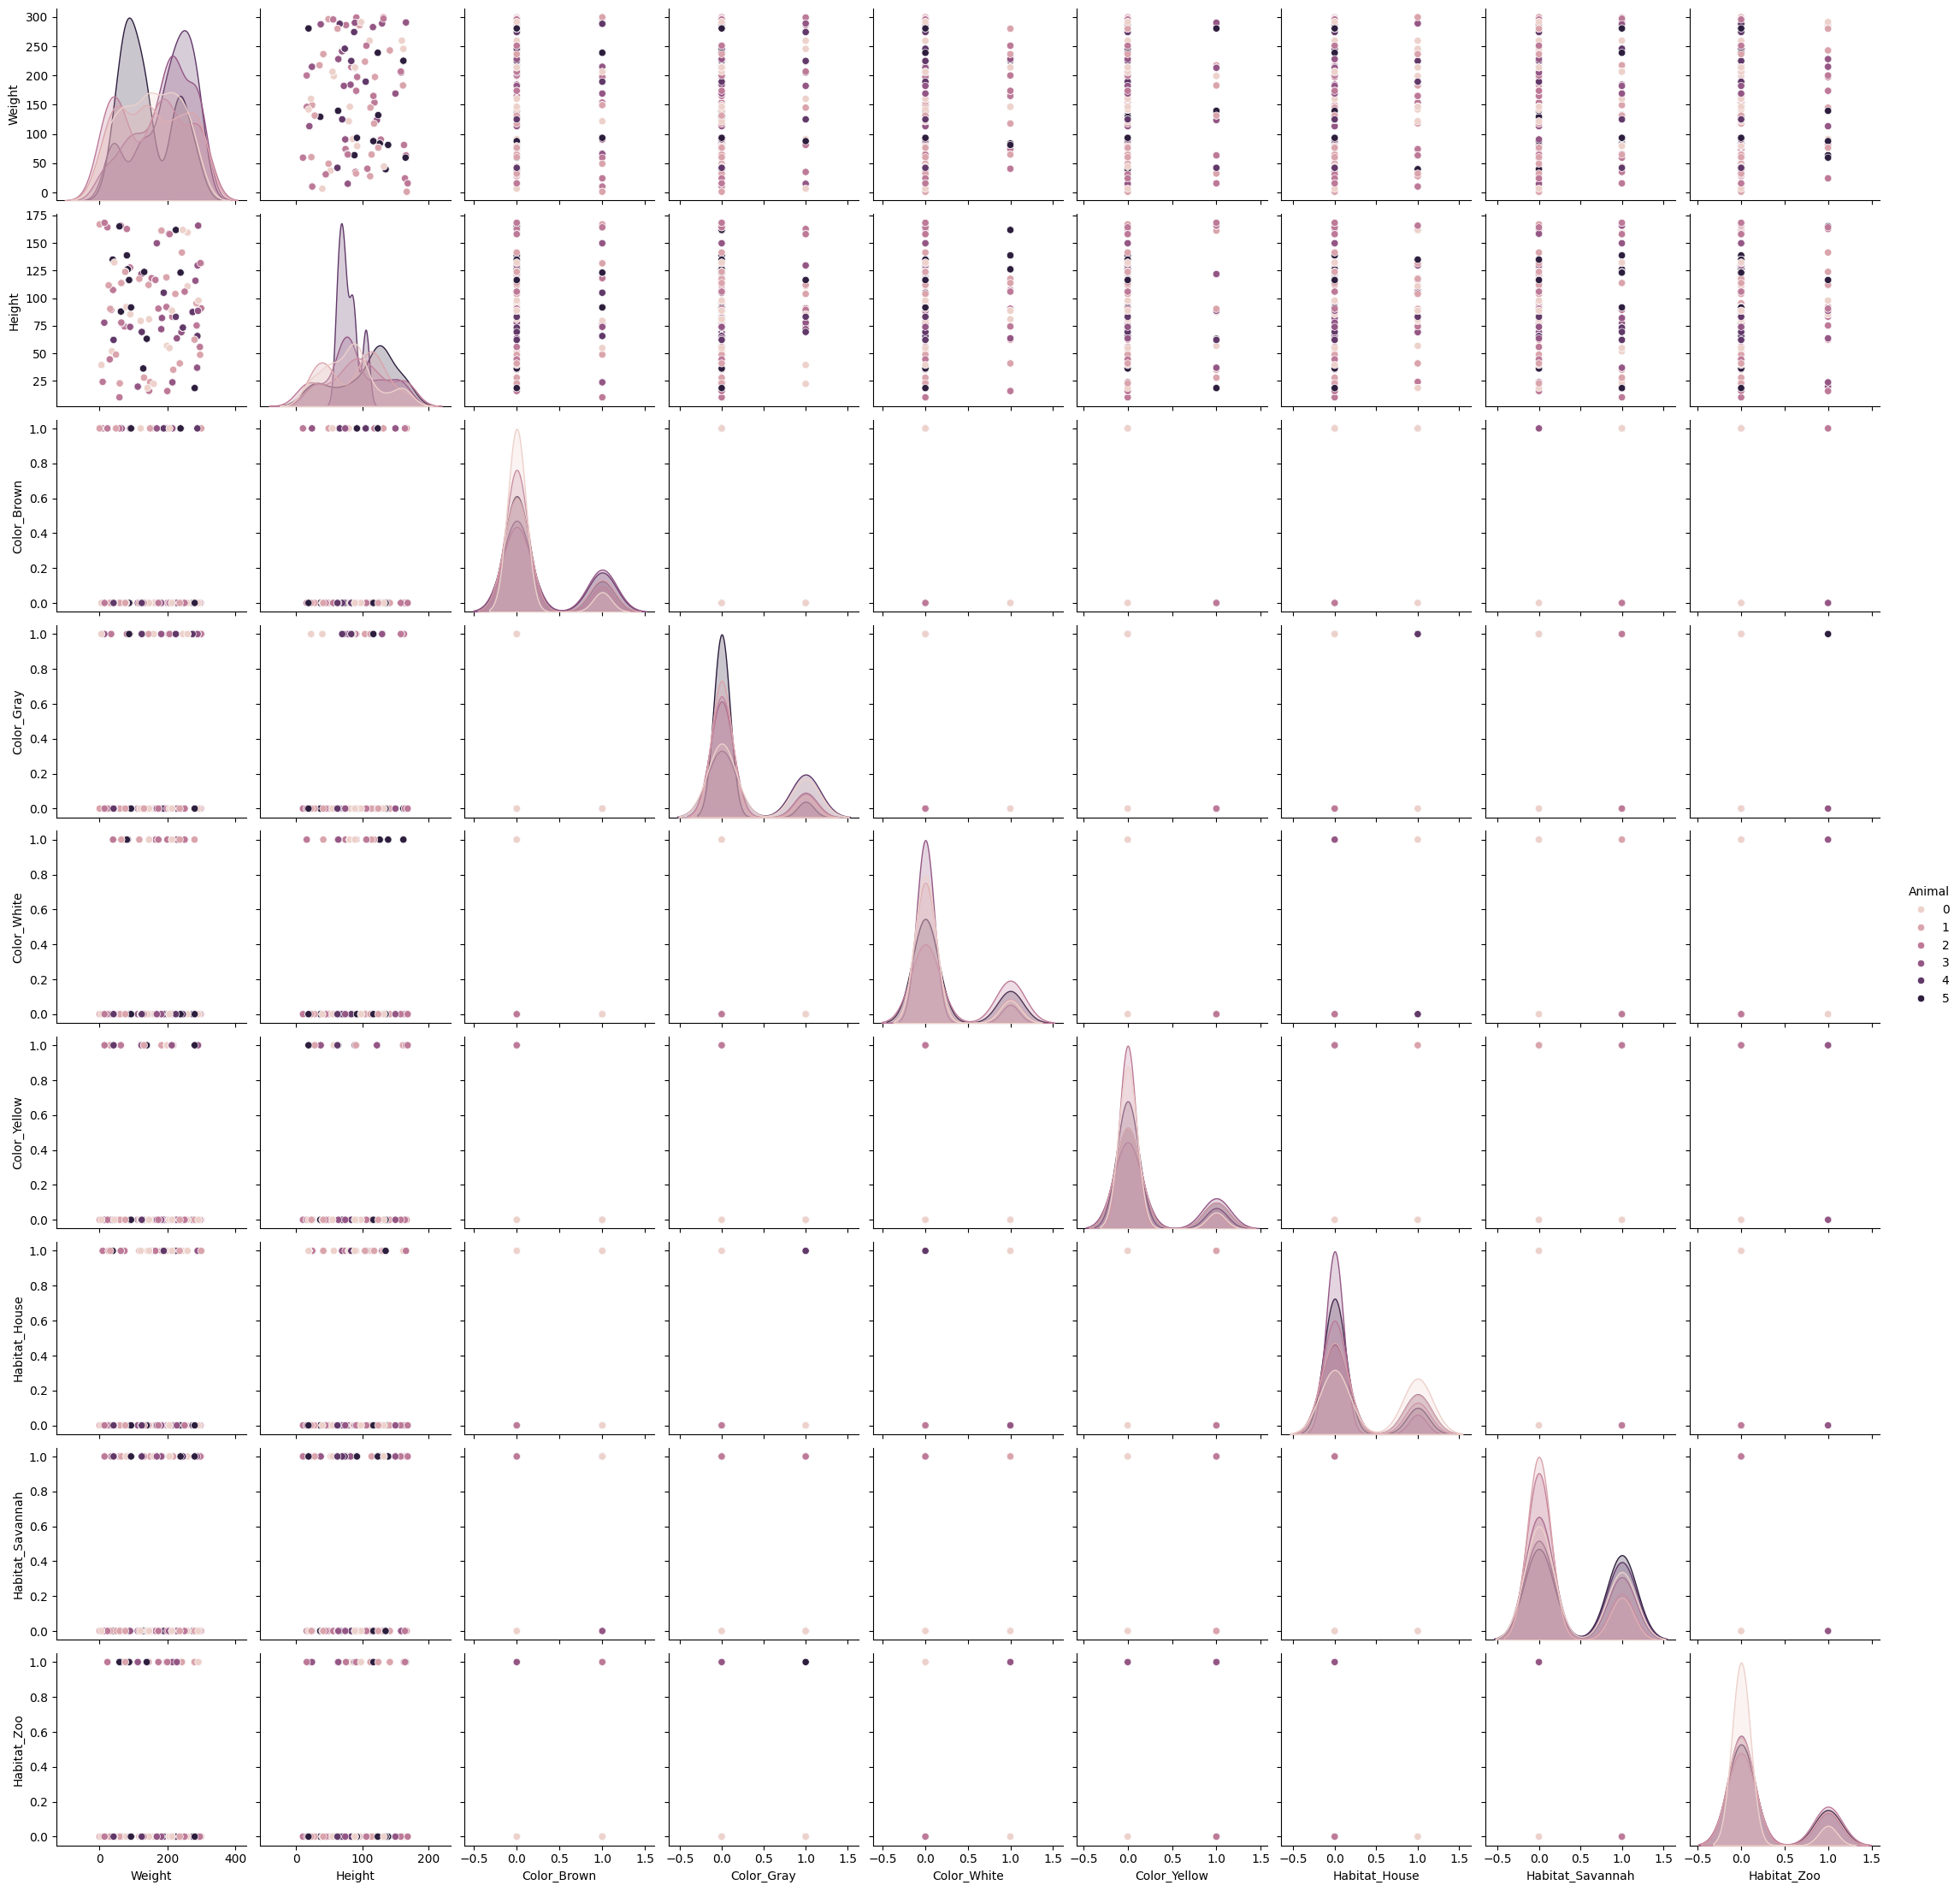

In [256]:
sns.pairplot(plot,vars=(x.columns)
,hue='Animal')

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.3)

In [258]:
x_cols=x.columns
x_cols

Index(['Weight', 'Height', 'Color_Brown', 'Color_Gray', 'Color_White',
       'Color_Yellow', 'Habitat_House', 'Habitat_Savannah', 'Habitat_Zoo'],
      dtype='object')

In [259]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

preprocessor=ColumnTransformer(
    transformers=[
        ('minmax',MinMaxScaler(),x_cols)
    ]
)

In [260]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as ImbPipeline

pipeline=ImbPipeline(
    steps=[
        ('preprocess',preprocessor),
        ('model',RandomForestClassifier(random_state=42))
    ]
)

In [262]:
pipeline.fit(x_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('minmax', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [264]:
ypred=pipeline.predict(x_train)
ypred

array([5, 4, 3, 4, 4, 0, 4, 4, 4, 3, 0, 5, 0, 4, 2, 4, 3, 1, 0, 2, 1, 3,
       4, 2, 2, 3, 1, 0, 2, 1, 3, 5, 0, 0, 3, 4, 3, 4, 2, 3, 0, 2, 2, 1,
       0, 1, 5, 0, 1, 2, 4, 0, 5, 3, 3, 5, 2, 1, 1, 4, 2, 3, 3, 0, 4, 5,
       4, 1, 3, 0, 1, 3, 3, 3, 0, 2, 2, 5, 5, 3, 0, 2, 3, 0, 0, 3, 5, 5,
       4, 3, 3, 1, 3, 2, 3, 5, 1, 2, 4, 0, 5, 4, 2, 1, 3, 5, 1, 1, 1, 4,
       0, 4, 4, 2, 5, 1, 3, 1, 2, 3, 2, 0, 1, 3, 2, 1, 5, 0, 0, 5, 1, 0,
       2, 1, 2, 4, 1, 4, 0, 5, 4, 5, 3, 4, 5, 5, 2, 2, 5, 2, 1, 3, 1, 2,
       1, 2, 3, 1, 5, 1, 0, 0, 4, 2, 0, 3, 3, 5, 4, 0, 3, 1, 0, 1, 5, 4,
       4, 5, 1, 5, 1, 3, 4, 2, 2, 3, 0, 5, 1, 2, 2, 4, 3, 4, 4, 5, 0, 4,
       0, 0, 5, 2, 5, 5, 2, 3, 4, 5, 3, 5, 3, 3, 2, 2, 2, 5, 5, 0, 1, 3,
       4, 1, 5, 1, 2, 1, 2, 4, 3, 3, 2, 4, 1, 0, 3, 3, 3, 4, 3, 2, 0, 1,
       4, 2, 0, 1, 0, 4, 2, 0, 3, 4, 3, 4, 0, 0, 2, 0, 1, 2, 0, 0, 4, 2,
       4, 0, 5, 4, 1, 5, 3, 5, 4, 1, 0, 3, 5, 3, 3, 2, 1, 4, 3, 5, 3, 2,
       5, 2, 5, 2, 2, 0, 5, 2, 1, 4, 3, 0, 5, 2, 3,

In [ ]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_train
res['predicted']=ypred
res.reset_index(drop=True)
res

,actual,predicted
650,5,5
918,4,4
926,3,3
377,4,4
939,4,4
...,...,...
106,0,0
270,3,3
860,2,2
435,1,1


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       117
           1       1.00      1.00      1.00       111
           2       1.00      1.00      1.00       116
           3       1.00      1.00      1.00       114
           4       1.00      1.00      1.00       117
           5       1.00      1.00      1.00       122

    accuracy                           1.00       697
   macro avg       1.00      1.00      1.00       697
weighted avg       1.00      1.00      1.00       697

1.0


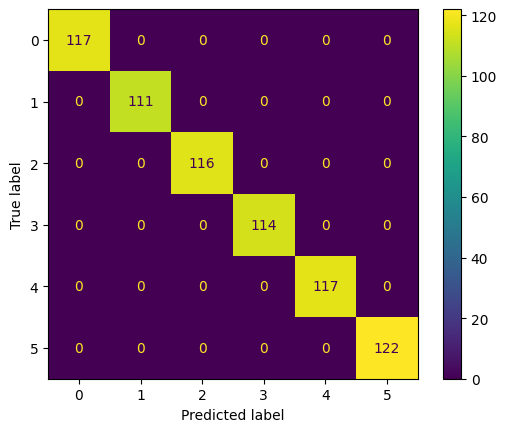

In [266]:
from sklearn.metrics import classification_report,accuracy_score,ConfusionMatrixDisplay
print(classification_report(ypred,y_train))
print(accuracy_score(ypred,y_train))
ConfusionMatrixDisplay.from_estimator(pipeline, x_train, y_train)
plt.show()

In [267]:
ypred=pipeline.predict(x_test)
ypred

array([3, 2, 3, 1, 4, 2, 2, 1, 5, 2, 2, 4, 0, 3, 3, 0, 3, 2, 4, 5, 3, 2,
       0, 5, 3, 5, 4, 1, 1, 2, 0, 5, 2, 3, 0, 1, 0, 1, 1, 0, 3, 1, 3, 3,
       3, 4, 3, 3, 4, 0, 1, 1, 4, 2, 0, 4, 0, 2, 4, 0, 2, 5, 0, 1, 4, 0,
       3, 4, 2, 5, 1, 2, 3, 0, 5, 3, 1, 3, 5, 0, 0, 4, 4, 3, 1, 4, 2, 1,
       4, 4, 4, 5, 5, 0, 5, 1, 2, 4, 5, 1, 3, 4, 0, 1, 1, 1, 3, 3, 0, 4,
       0, 5, 4, 3, 4, 1, 2, 3, 5, 3, 4, 0, 5, 0, 0, 1, 3, 4, 5, 3, 2, 0,
       3, 2, 2, 3, 2, 1, 4, 5, 4, 4, 4, 5, 4, 5, 5, 1, 3, 2, 3, 2, 0, 4,
       2, 0, 3, 1, 3, 1, 1, 4, 5, 0, 3, 2, 1, 5, 3, 2, 0, 2, 1, 2, 0, 3,
       5, 5, 1, 4, 1, 4, 1, 4, 2, 5, 0, 0, 1, 1, 0, 4, 3, 1, 5, 1, 4, 2,
       4, 4, 5, 3, 0, 5, 5, 1, 3, 1, 2, 0, 0, 1, 0, 4, 0, 0, 2, 0, 3, 4,
       1, 5, 4, 2, 1, 4, 3, 3, 3, 1, 2, 4, 1, 4, 2, 5, 2, 5, 0, 2, 1, 3,
       5, 0, 4, 0, 3, 1, 1, 3, 1, 2, 1, 4, 0, 5, 4, 2, 4, 1, 3, 0, 2, 2,
       1, 2, 5, 4, 5, 0, 2, 3, 5, 1, 1, 3, 5, 0, 2, 3, 5, 5, 2, 2, 3, 5,
       2, 5, 3, 5, 0, 2, 1, 2, 0, 1, 1, 2, 0])

In [268]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_test
res['predicted']=ypred
res.reset_index(drop=True)
res

,actual,predicted
832,3,3
970,2,2
96,3,3
587,1,1
450,4,4
...,...,...
7,0,0
155,1,1
539,1,1
994,2,2


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        55
           2       1.00      1.00      1.00        50
           3       1.00      1.00      1.00        52
           4       1.00      1.00      1.00        49
           5       1.00      1.00      1.00        44

    accuracy                           1.00       299
   macro avg       1.00      1.00      1.00       299
weighted avg       1.00      1.00      1.00       299

1.0


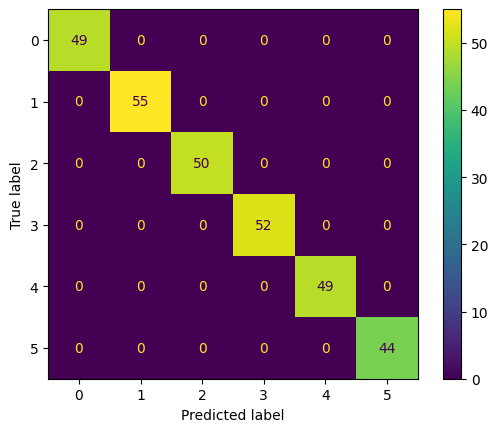

In [269]:
from sklearn.metrics import classification_report,accuracy_score,ConfusionMatrixDisplay
print(classification_report(ypred,y_test))
print(accuracy_score(ypred,y_test))
ConfusionMatrixDisplay.from_estimator(pipeline, x_test, y_test)
plt.show()